1. Problem Statement
2. Data Loading
3. Exploratory Data Analysis
4. Attribute Extraction
5. Labeling Strategy
6. Model Training
7. Model Evaluation
8. Tier Assignment
9. Evidence Extraction
10. Conclusions

In [1]:
# import libraries

In [2]:
import numpy as np
import pandas as pd
import seaborn as sns
from nltk.sentiment import SentimentIntensityAnalyzer

from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report

In [3]:
df = pd.read_csv("tripadvisor_hotel_reviews.csv")
df.head()

,Review,Rating
0,nice hotel expensive parking got good deal sta...,4
1,ok nothing special charge diamond member hilto...,2
2,nice rooms not 4* experience hotel monaco seat...,3
3,"unique, great stay, wonderful time hotel monac...",5
4,"great stay great stay, went seahawk game aweso...",5


## 1. Dataset Exploration (EDA)

In [4]:
## Dataset Statistics

In [5]:
df.shape

(20491, 2)

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20491 entries, 0 to 20490
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   Review  20491 non-null  object
 1   Rating  20491 non-null  int64 
dtypes: int64(1), object(1)
memory usage: 320.3+ KB


In [7]:
df["Review"].str.len().describe()

count    20491.000000
mean       724.896833
std        689.101024
min         44.000000
25%        339.000000
50%        537.000000
75%        859.000000
max      13501.000000
Name: Review, dtype: float64

In [8]:
df["Rating"].value_counts()

Rating
5    9054
4    6039
3    2184
2    1793
1    1421
Name: count, dtype: int64

In [9]:
(df["Rating"].value_counts(normalize=True) * 100).round(2)

Rating
5    44.19
4    29.47
3    10.66
2     8.75
1     6.93
Name: proportion, dtype: float64

In [10]:
#review length distribution
df["review_length"] = df["Review"].apply(len)
df["review_length"]

0         593
1        1689
2        1427
3         600
4        1281
         ... 
20486     733
20487     306
20488     443
20489    5557
20490     620
Name: review_length, Length: 20491, dtype: int64

In [11]:
#Plot
import seaborn as sns

<Axes: xlabel='review_length', ylabel='Count'>

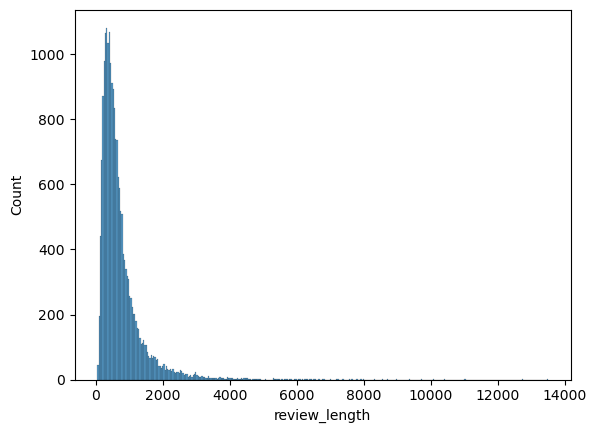

In [12]:
sns.histplot(df["review_length"])

<Axes: xlabel='Rating', ylabel='count'>

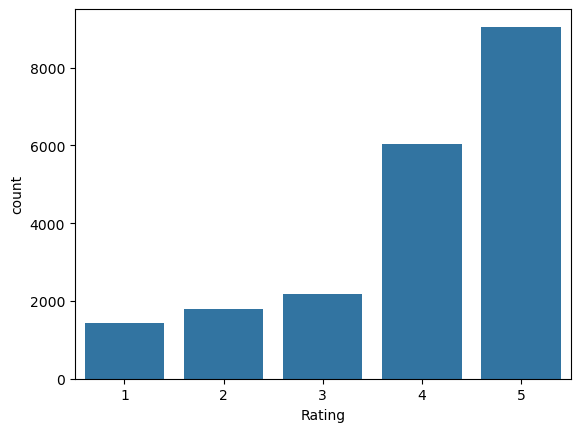

In [13]:
# rating distribution
sns.countplot(x="Rating", data=df)

## Labeling Strategy

In [14]:
# Step 1: Split Reviews into Sentences
import nltk
#sentences = nltk.sent_tokenize(Review)
#sentences = nltk.sent_tokenize(df["Review"].iloc[0])
#sentences

In [15]:
#df["sentences"] = df["Review"].apply(nltk.sent_tokenize)

In [16]:
for i in range(5):
    print(df["Review"].iloc[i])
    print("-"*100)

nice hotel expensive parking got good deal stay hotel anniversary, arrived late evening took advice previous reviews did valet parking, check quick easy, little disappointed non-existent view room room clean nice size, bed comfortable woke stiff neck high pillows, not soundproof like heard music room night morning loud bangs doors opening closing hear people talking hallway, maybe just noisy neighbors, aveda bath products nice, did not goldfish stay nice touch taken advantage staying longer, location great walking distance shopping, overall nice experience having pay 40 parking night,  
----------------------------------------------------------------------------------------------------
ok nothing special charge diamond member hilton decided chain shot 20th anniversary seattle, start booked suite paid extra website description not, suite bedroom bathroom standard hotel room, took printed reservation desk showed said things like tv couch ect desk clerk told oh mixed suites description ki

In [17]:
"""df["sentences"] = df["Review"].apply(
    lambda x: [s.strip() for s in x.split(",") if s.strip()]
)"""

'df["sentences"] = df["Review"].apply(\n    lambda x: [s.strip() for s in x.split(",") if s.strip()]\n)'

In [18]:
#df["sentences"]

In [19]:
df["segments"] = df["Review"].apply(
    lambda x: [s.strip() for s in x.split(",") if s.strip()]
)

In [20]:
df["segments"]

0        [nice hotel expensive parking got good deal st...
1        [ok nothing special charge diamond member hilt...
2        [nice rooms not 4* experience hotel monaco sea...
3        [unique, great stay, wonderful time hotel mona...
4        [great stay great stay, went seahawk game awes...
                               ...                        
20486    [best kept secret 3rd time staying charm, not ...
20487    [great location price view hotel great quick p...
20488    [ok just looks nice modern outside, desk staff...
20489    [hotel theft ruined vacation hotel opened sept...
20490    [people talking, ca n't believe excellent rati...
Name: segments, Length: 20491, dtype: object

## Attributes to extract

In [21]:
## Attribute Labeling

In [22]:
attributes = [
    "cleanliness",
    "staff_service",
    "wifi",
    "bed_quality",
    "room_size"
]

In [23]:
# Create Keyword Dictionaries

In [24]:
attribute_keywords = {
    
    "cleanliness": [
        "clean", "dirty", "spotless",
        "hygienic", "dusty", "stain",
        "filthy", "tidy"
    ],

    "staff_service": [
        "staff", "service", "reception",
        "manager", "employee",
        "helpful", "friendly", "rude"
    ],

    "wifi": [
        "wifi", "wi-fi",
        "internet", "network",
        "connection"
    ],

    "bed_quality": [
        "bed", "mattress",
        "pillow", "sleep",
        "comfortable", "uncomfortable"
    ],

    "room_size": [
        "spacious", "small",
        "large", "tiny",
        "cramped", "roomy",
        "size"
    ]
}

In [25]:
# Function to Detect Attributes

In [26]:
"""def find_attributes(segment):

    found = []
    segment = segment.lower()

    for attribute, keywords in attribute_keywords.items():

        if any(keyword in segment for keyword in keywords):
            found.append(attribute)

    return found"""

'def find_attributes(segment):\n\n    found = []\n    segment = segment.lower()\n\n    for attribute, keywords in attribute_keywords.items():\n\n        if any(keyword in segment for keyword in keywords):\n            found.append(attribute)\n\n    return found'

In [27]:
import re

def find_attributes(segment):

    segment = segment.lower()

    words = set(re.findall(r'\b\w+\b', segment))

    found = []

    for attr, keywords in attribute_keywords.items():

        if any(k in words for k in keywords):
            found.append(attr)

    return found

In [28]:
#test
find_attributes(
    "room room clean nice size"
)

['cleanliness', 'room_size']

In [29]:
# Apply on All Segments

In [30]:
segment_df = df.explode("segments")

segment_df = segment_df.rename(
    columns={"segments":"segment"}
)

In [31]:
segment_df

,Review,Rating,review_length,segment
0,nice hotel expensive parking got good deal sta...,4,593,nice hotel expensive parking got good deal sta...
0,nice hotel expensive parking got good deal sta...,4,593,arrived late evening took advice previous revi...
0,nice hotel expensive parking got good deal sta...,4,593,check quick easy
0,nice hotel expensive parking got good deal sta...,4,593,little disappointed non-existent view room roo...
0,nice hotel expensive parking got good deal sta...,4,593,bed comfortable woke stiff neck high pillows
...,...,...,...,...
20490,"people talking, ca n't believe excellent ratin...",2,620,lots guys hanging desk hallway
20490,"people talking, ca n't believe excellent ratin...",2,620,girlfriend swears house prostitution
20490,"people talking, ca n't believe excellent ratin...",2,620,patricia did arrange taxi following morning st...
20490,"people talking, ca n't believe excellent ratin...",2,620,rooms clean large bathroom small


In [32]:
#Create attribute column

In [33]:
segment_df["attributes"] = (segment_df["segment"].apply(find_attributes))

In [34]:
# Keep only useful segments

In [35]:
segment_df = segment_df[segment_df["attributes"].str.len() > 0]

In [36]:
segment_df

,Review,Rating,review_length,segment,attributes
0,nice hotel expensive parking got good deal sta...,4,593,little disappointed non-existent view room roo...,"[cleanliness, room_size]"
0,nice hotel expensive parking got good deal sta...,4,593,bed comfortable woke stiff neck high pillows,[bed_quality]
1,ok nothing special charge diamond member hilto...,2,1689,send kimpton preferred guest website email ask...,[staff_service]
1,ok nothing special charge diamond member hilto...,2,1689,guess tell concerned guest.the staff ranged in...,[staff_service]
1,ok nothing special charge diamond member hilto...,2,1689,arrival no champagne strawberries no foam pill...,[staff_service]
...,...,...,...,...,...
20489,hotel theft ruined vacation hotel opened sept ...,1,5557,theft staff fine save manager professional apo...,[staff_service]
20489,hotel theft ruined vacation hotel opened sept ...,1,5557,manager offered weakest apology night occured ...,[staff_service]
20489,hotel theft ruined vacation hotel opened sept ...,1,5557,cctv cameras helpful not entrance affixed terr...,[staff_service]
20490,"people talking, ca n't believe excellent ratin...",2,620,yes patricia extremely helpful fluent language...,[staff_service]


In [37]:
segment_df["attributes"].explode().value_counts()

attributes
staff_service    30198
room_size        13859
cleanliness      10721
bed_quality       9656
wifi              2467
Name: count, dtype: int64

In [38]:
## Use Review Rating as Weak Label

In [39]:
def rating_to_sentiment(rating):
    
    if rating >= 4:
        return "positive"
    
    elif rating <= 2:
        return "negative"
    
    return "neutral"

In [40]:
segment_df["sentiment"] = (
    segment_df["Rating"]
    .apply(rating_to_sentiment)
)

C:\Users\Acer\AppData\Local\Temp\ipykernel_24256\3383418074.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  segment_df["sentiment"] = (


In [41]:
segment_df["sentiment"].value_counts()

sentiment
positive    40741
negative     9375
neutral      6348
Name: count, dtype: int64

In [42]:
segment_df

,Review,Rating,review_length,segment,attributes,sentiment
0,nice hotel expensive parking got good deal sta...,4,593,little disappointed non-existent view room roo...,"[cleanliness, room_size]",positive
0,nice hotel expensive parking got good deal sta...,4,593,bed comfortable woke stiff neck high pillows,[bed_quality],positive
1,ok nothing special charge diamond member hilto...,2,1689,send kimpton preferred guest website email ask...,[staff_service],negative
1,ok nothing special charge diamond member hilto...,2,1689,guess tell concerned guest.the staff ranged in...,[staff_service],negative
1,ok nothing special charge diamond member hilto...,2,1689,arrival no champagne strawberries no foam pill...,[staff_service],negative
...,...,...,...,...,...,...
20489,hotel theft ruined vacation hotel opened sept ...,1,5557,theft staff fine save manager professional apo...,[staff_service],negative
20489,hotel theft ruined vacation hotel opened sept ...,1,5557,manager offered weakest apology night occured ...,[staff_service],negative
20489,hotel theft ruined vacation hotel opened sept ...,1,5557,cctv cameras helpful not entrance affixed terr...,[staff_service],negative
20490,"people talking, ca n't believe excellent ratin...",2,620,yes patricia extremely helpful fluent language...,[staff_service],negative


In [43]:
segment_df.sample(20)[
    ["segment", "attributes", "sentiment"]
]

,segment,attributes,sentiment
14633,pillows sooooo comfy bed,[bed_quality],positive
18604,hotel island beach service excellent,[staff_service],positive
4345,small comment breakfast service chaotic fades ...,"[staff_service, room_size]",positive
2257,finally service excellent,[staff_service],positive
7110,room amazing clean tidy maids really great job,[cleanliness],positive
19298,decent size bathroom half wall open stall type...,[room_size],neutral
3536,excellent holiday stayed resort nov 1-15 compl...,[staff_service],positive
17588,giselle contacted hotels alberto train running...,[room_size],positive
943,staff professional attentive experienced,[staff_service],positive
14187,exceedingly poor service mildewed rooms mars d...,[staff_service],negative


In [44]:
from nltk.sentiment import SentimentIntensityAnalyzer

sia = SentimentIntensityAnalyzer()

segment_df["vader_score"] = segment_df["segment"].apply(
    lambda x: sia.polarity_scores(x)["compound"]
)

def vader_sentiment(score):
    if score >= 0.2:
        return "positive"
    elif score <= -0.2:
        return "negative"
    return "neutral"

segment_df["vader_sentiment"] = (
    segment_df["vader_score"]
    .apply(vader_sentiment)
)

C:\Users\Acer\AppData\Local\Temp\ipykernel_24256\3027563286.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  segment_df["vader_score"] = segment_df["segment"].apply(
C:\Users\Acer\AppData\Local\Temp\ipykernel_24256\3027563286.py:16: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  segment_df["vader_sentiment"] = (


In [45]:
segment_df[
    ["segment",
     "sentiment",
     "vader_sentiment"]
].sample(20)

,segment,sentiment,vader_sentiment
13646,kind helpfull people people kind helpful.we no...,positive,positive
18318,way rate experience excellent not fair staff p...,positive,positive
4335,bathroom equisite showers heated towel rail la...,positive,neutral
7508,pool tiny consistency color puddle mystery liq...,neutral,neutral
9760,nothing fancy clean bit like basic novotel inside,neutral,neutral
971,decent self-service breakfast complimentary,positive,positive
3706,complaint complaint did not stop thoroughly en...,positive,negative
5280,tiles tired shall say no water pressure shower...,neutral,neutral
9931,rooms attractive spacious clean,positive,positive
6144,staff friendly helpful,positive,positive


In [46]:
train_df = segment_df.explode("attributes")

In [47]:
train_df.shape

(66901, 8)

In [48]:
train_df.head()

,Review,Rating,review_length,segment,attributes,sentiment,vader_score,vader_sentiment
0,nice hotel expensive parking got good deal sta...,4,593,little disappointed non-existent view room roo...,cleanliness,positive,0.4005,positive
0,nice hotel expensive parking got good deal sta...,4,593,little disappointed non-existent view room roo...,room_size,positive,0.4005,positive
0,nice hotel expensive parking got good deal sta...,4,593,bed comfortable woke stiff neck high pillows,bed_quality,positive,0.5106,positive
1,ok nothing special charge diamond member hilto...,2,1689,send kimpton preferred guest website email ask...,staff_service,negative,-0.6870,negative
1,ok nothing special charge diamond member hilto...,2,1689,guess tell concerned guest.the staff ranged in...,staff_service,negative,-0.4822,negative


In [49]:
pd.crosstab(
    train_df["attributes"],
    train_df["sentiment"]
)

sentiment,negative,neutral,positive
attributes,,,
bed_quality,1690,1093,6873
cleanliness,1521,1288,7912
room_size,1774,1769,10316
staff_service,5214,2983,22001
wifi,358,335,1774


In [50]:
train_df["attributes"].value_counts()

attributes
staff_service    30198
room_size        13859
cleanliness      10721
bed_quality       9656
wifi              2467
Name: count, dtype: int64

In [51]:
import os

os.makedirs("data", exist_ok=True)

train_df.head(10000).to_csv(
    "data/labeled_segments_sample.csv",
    index=False
)

## Modelling

Train one model per attribute.

In [52]:
# 1. First Model

In [53]:
clean_df = train_df[train_df["attributes"] == "cleanliness"]

In [54]:
clean_df.shape

(10721, 8)

In [55]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    clean_df["segment"],
    clean_df["sentiment"],
    test_size=0.2,
    random_state=42,
    stratify=clean_df["sentiment"]
)

In [56]:
from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression

In [57]:
clean_model = Pipeline([
    (
        "tfidf",
        TfidfVectorizer(
            max_features=5000,
            ngram_range=(1,2)
        )
    ),
    (
        "clf",
        LogisticRegression(
            max_iter=1000,
            class_weight="balanced"
        )
    )
])

Why class_weight="balanced"

Because the classes are imbalanced.

In [58]:
#Train clean_model
clean_model.fit(X_train, y_train)

Pipeline(steps=[('tfidf',
                 TfidfVectorizer(max_features=5000, ngram_range=(1, 2))),
                ('clf',
                 LogisticRegression(class_weight='balanced', max_iter=1000))])

In [59]:
#predict
y_pred = clean_model.predict(X_test)

In [60]:
# Evaluate
from sklearn.metrics import classification_report
print(classification_report(y_test,y_pred))

              precision    recall  f1-score   support

    negative       0.58      0.67      0.62       304
     neutral       0.19      0.32      0.24       258
    positive       0.87      0.74      0.80      1583

    accuracy                           0.68      2145
   macro avg       0.54      0.58      0.55      2145
weighted avg       0.75      0.68      0.71      2145



In [61]:
# Second model (staff)

In [62]:
staff_df = train_df[train_df["attributes"] == "staff_service"]

In [63]:
staff_df.shape

(30198, 8)

In [64]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    staff_df["segment"],
    staff_df["sentiment"],
    test_size=0.2,
    random_state=42,
    stratify=staff_df["sentiment"]
)

In [65]:
from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression

In [66]:
staff_model = Pipeline([
    (
        "tfidf",
        TfidfVectorizer(
            max_features=5000,
            ngram_range=(1,2)
        )
    ),
    (
        "clf",
        LogisticRegression(
            max_iter=1000,
            class_weight="balanced"
        )
    )
])

In [67]:
#Train
staff_model.fit(X_train, y_train)

Pipeline(steps=[('tfidf',
                 TfidfVectorizer(max_features=5000, ngram_range=(1, 2))),
                ('clf',
                 LogisticRegression(class_weight='balanced', max_iter=1000))])

In [68]:
#predict
y_pred = staff_model.predict(X_test)

In [69]:
# Evaluate
from sklearn.metrics import classification_report
print(classification_report(y_test,y_pred))

              precision    recall  f1-score   support

    negative       0.47      0.61      0.53      1043
     neutral       0.16      0.31      0.21       597
    positive       0.89      0.70      0.78      4400

    accuracy                           0.65      6040
   macro avg       0.50      0.54      0.51      6040
weighted avg       0.74      0.65      0.68      6040



In [70]:
# Third model (wifi)
wifi_df = train_df[train_df["attributes"] == "wifi"]
wifi_df.shape


(2467, 8)

In [71]:
X_train, X_test, y_train, y_test = train_test_split(
    wifi_df["segment"],
    wifi_df["sentiment"],
    test_size=0.2,
    random_state=42,
    stratify=wifi_df["sentiment"]
)

In [72]:
wifi_model = Pipeline([
    (
        "tfidf",
        TfidfVectorizer(
            max_features=5000,
            ngram_range=(1,2)
        )
    ),
    (
        "clf",
        LogisticRegression(
            max_iter=1000,
            class_weight="balanced"
        )
    )
])

In [73]:
#Train
wifi_model.fit(X_train, y_train)
#predict
y_pred = wifi_model.predict(X_test)

# Evaluate

print(classification_report(y_test,y_pred))

              precision    recall  f1-score   support

    negative       0.25      0.29      0.27        72
     neutral       0.22      0.24      0.23        67
    positive       0.79      0.75      0.77       355

    accuracy                           0.62       494
   macro avg       0.42      0.43      0.42       494
weighted avg       0.64      0.62      0.62       494



In [74]:
# 4 train model 
room_df = train_df[train_df["attributes"] == "room_size"]
room_df.shape


(13859, 8)

In [75]:
X_train, X_test, y_train, y_test = train_test_split(
    room_df["segment"],
    room_df["sentiment"],
    test_size=0.2,
    random_state=42,
    stratify=room_df["sentiment"]
)

In [76]:
## Fourth Model (room_size)
room_model = Pipeline([
    (
        "tfidf",
        TfidfVectorizer(
            max_features=5000,
            ngram_range=(1,2)
        )
    ),
    (
        "clf",
        LogisticRegression(
            max_iter=1000,
            class_weight="balanced"
        )
    )
])

In [77]:
room_model.fit(X_train, y_train)
y_pred = room_model.predict(X_test)
print(classification_report(y_test,y_pred))

              precision    recall  f1-score   support

    negative       0.33      0.49      0.39       355
     neutral       0.22      0.35      0.27       354
    positive       0.85      0.69      0.77      2063

    accuracy                           0.62      2772
   macro avg       0.47      0.51      0.48      2772
weighted avg       0.71      0.62      0.65      2772



In [78]:
# Fifth model (bed_quality)
bed_df = train_df[train_df["attributes"] == "bed_quality"]
bed_df.shape

(9656, 8)

In [79]:
X_train, X_test, y_train, y_test = train_test_split(
    bed_df["segment"],
    bed_df["sentiment"],
    test_size=0.2,
    random_state=42,
    stratify=bed_df["sentiment"]
)

In [80]:
bed_model = Pipeline([
    (
        "tfidf",
        TfidfVectorizer(
            max_features=5000,
            ngram_range=(1,2)
        )
    ),
    (
        "clf",
        LogisticRegression(
            max_iter=1000,
            class_weight="balanced"
        )
    )
])

In [81]:
bed_model.fit(X_train, y_train)
y_pred = bed_model.predict(X_test)
print(classification_report(y_test,y_pred))

              precision    recall  f1-score   support

    negative       0.47      0.65      0.54       338
     neutral       0.19      0.28      0.22       219
    positive       0.88      0.73      0.80      1375

    accuracy                           0.66      1932
   macro avg       0.51      0.55      0.52      1932
weighted avg       0.73      0.66      0.69      1932



In [82]:
# Store All Models
models = {
    "cleanliness": clean_model,
    "staff_service": staff_model,
    "wifi": wifi_model,
    "room_size": room_model,
    "bed_quality": bed_model
}

In [83]:
os.makedirs("models", exist_ok=True)

In [84]:
import joblib

joblib.dump(clean_model, "models/clean_model.pkl")
joblib.dump(staff_model, "models/staff_model.pkl")
joblib.dump(wifi_model, "models/wifi_model.pkl")
joblib.dump(room_model, "models/room_model.pkl")
joblib.dump(bed_model, "models/bed_model.pkl")

['models/bed_model.pkl']

In [85]:
#Step 1: Create Prediction Dataset

In [86]:
pred_df = train_df.copy()

pred_df["predicted_sentiment"] = None

In [87]:
#Step 2: Generate Predictions

In [88]:
for attr, model in models.items():

    mask = pred_df["attributes"] == attr

    pred_df.loc[mask, "predicted_sentiment"] = (
        model.predict(
            pred_df.loc[mask, "segment"]
        )
    )

In [89]:
pred_df[
    ["segment",
     "attributes",
     "predicted_sentiment"]
].head()

,segment,attributes,predicted_sentiment
0,little disappointed non-existent view room roo...,cleanliness,positive
0,little disappointed non-existent view room roo...,room_size,positive
0,bed comfortable woke stiff neck high pillows,bed_quality,positive
1,send kimpton preferred guest website email ask...,staff_service,negative
1,guess tell concerned guest.the staff ranged in...,staff_service,negative


In [90]:
#Step 3: Convert Predictions to Scores

In [91]:
score_map = {
    "positive": 1,
    "neutral": 0,
    "negative": -1
}

pred_df["pred_score"] = (
    pred_df["predicted_sentiment"]
    .map(score_map)
)

In [92]:
pred_df["pred_score"].value_counts()

pred_score
 1    39458
-1    14091
 0    13352
Name: count, dtype: int64

In [93]:
#Step 4: Aggregate Scores

In [94]:
#Average score for each Review × Attribute.

In [95]:
attribute_scores = (
    pred_df
    .groupby(
        ["Review", "attributes"],
        as_index=False
    )["pred_score"]
    .mean()
)

In [96]:
attribute_scores.head()

,Review,attributes,pred_score
0,"1 best hotels new york, hotel absoutly brillia...",bed_quality,1.0
1,"1 best hotels new york, hotel absoutly brillia...",staff_service,1.0
2,"1 best small hotel venice forget rest, secret ...",cleanliness,1.0
3,"1 best small hotel venice forget rest, secret ...",room_size,1.0
4,"1 choice florence hotel globus fantastic, room...",bed_quality,1.0


In [97]:
#Step 5: Calculate Evidence Count

In [98]:
evidence_count_df = (
    pred_df
    .groupby(
        ["Review", "attributes"],
        as_index=False
    )
    .size()
    .rename(
        columns={"size": "evidence_count"}
    )
)

In [99]:
evidence_count_df.head()

,Review,attributes,evidence_count
0,"1 best hotels new york, hotel absoutly brillia...",bed_quality,1
1,"1 best hotels new york, hotel absoutly brillia...",staff_service,1
2,"1 best small hotel venice forget rest, secret ...",cleanliness,1
3,"1 best small hotel venice forget rest, secret ...",room_size,5
4,"1 choice florence hotel globus fantastic, room...",bed_quality,2


In [100]:
# Step 6: Merge Evidence Counts

In [101]:
attribute_scores = attribute_scores.merge(
    evidence_count_df,
    on=["Review", "attributes"],
    how="left"
)

In [102]:
attribute_scores.head()

,Review,attributes,pred_score,evidence_count
0,"1 best hotels new york, hotel absoutly brillia...",bed_quality,1.0,1
1,"1 best hotels new york, hotel absoutly brillia...",staff_service,1.0,1
2,"1 best small hotel venice forget rest, secret ...",cleanliness,1.0,1
3,"1 best small hotel venice forget rest, secret ...",room_size,1.0,5
4,"1 choice florence hotel globus fantastic, room...",bed_quality,1.0,2


In [103]:
# Step 7: Tier Assignment

In [104]:
def assign_tier(score, evidence_count):

    if score >= 0.75 and evidence_count >= 2:
        return "Elite"

    elif score >= 0.25:
        return "Superior"

    elif score >= -0.25:
        return "Premium"

    else:
        return "Fail"

In [105]:
attribute_scores["tier"] = (
    attribute_scores.apply(
        lambda row: assign_tier(
            row["pred_score"],
            row["evidence_count"]
        ),
        axis=1
    )
)

In [106]:
# Step 8: Tier Distribution

In [107]:
attribute_scores["tier"].value_counts()

tier
Superior    22651
Premium      8422
Fail         7354
Elite        5132
Name: count, dtype: int64

In [108]:
#Step 9: Confidence Score

In [109]:
# handle low evidence
attribute_scores["confidence"] = (
    attribute_scores["evidence_count"]
    .apply(
        lambda x: "High"
        if x >= 2
        else "Low"
    )
)

In [110]:
# Step 10: Evidence Extraction

In [111]:
def get_evidence(review_text, attribute):

    evidence = pred_df[
        (pred_df["Review"] == review_text)
        &
        (pred_df["attributes"] == attribute)
    ][
        ["segment",
         "predicted_sentiment"]
    ]

    return evidence.sort_values(
         "predicted_sentiment"
    )

In [112]:
sample_review = (
    attribute_scores.iloc[0]["Review"]
)

sample_attribute = (
    attribute_scores.iloc[0]["attributes"]
)

get_evidence(
    sample_review,
    sample_attribute
)

,segment,predicted_sentiment
5929,bed nice comfortable,positive


In [113]:
#Step 11: Final Output Table

In [114]:
final_output = attribute_scores[
    [
        "Review",
        "attributes",
        "pred_score",
        "evidence_count",
        "confidence",
        "tier"
    ]
]

final_output.head()

,Review,attributes,pred_score,evidence_count,confidence,tier
0,"1 best hotels new york, hotel absoutly brillia...",bed_quality,1.0,1,Low,Superior
1,"1 best hotels new york, hotel absoutly brillia...",staff_service,1.0,1,Low,Superior
2,"1 best small hotel venice forget rest, secret ...",cleanliness,1.0,1,Low,Superior
3,"1 best small hotel venice forget rest, secret ...",room_size,1.0,5,High,Elite
4,"1 choice florence hotel globus fantastic, room...",bed_quality,1.0,2,High,Elite


In [115]:
sample_review = final_output.iloc[3]["Review"]
sample_attribute = final_output.iloc[3]["attributes"]

get_evidence(sample_review, sample_attribute)

,segment,predicted_sentiment
18173,1 best small hotel venice forget rest,positive
18173,great small hotel big beautiful rooms filled c...,positive
18173,right st. stae vaporetto stop 100 feet away ma...,positive
18173,booked room 9 large red bedroom converted kitchen,positive
18173,venice small rialto bridge 5-7 minute walk st....,positive


In [116]:
attribute_scores.shape

(43559, 6)

In [117]:
attribute_scores["tier"].value_counts()

tier
Superior    22651
Premium      8422
Fail         7354
Elite        5132
Name: count, dtype: int64

In [118]:
attribute_scores["confidence"].value_counts()

confidence
Low     29697
High    13862
Name: count, dtype: int64

In [119]:
os.makedirs("outputs", exist_ok=True)

In [120]:
# Outputs
attribute_scores.to_csv(
    "outputs/attribute_scores.csv",
    index=False
)

final_output.to_csv(
    "outputs/final_output.csv",
    index=False
)